In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, optimizers

In [15]:
img_size = (224, 224)
batch_size = 32
train_dir = r"C:\Users\Admin\OneDrive\Documents\File_save_bai_tap_random\Train\seg"
test_dir = r"C:\Users\Admin\OneDrive\Documents\File_save_bai_tap_random\Train\seg_test"

In [16]:
# 1. Data generators
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

num_classes = train_gen.num_classes

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [17]:
# 2. Transfer learning model
base_model = MobileNetV2(weights="imagenet", include_top=False,
                         input_shape=img_size + (3,))
base_model.trainable = False  # bước 1: chỉ train head

inputs = layers.Input(shape=img_size + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
# 3. Train
history = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 238s 667ms/step - accuracy: 0.5184 - loss: 1.2896 - val_accuracy: 0.7867 - val_loss: 0.6696
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 192s 546ms/step - accuracy: 0.7773 - loss: 0.6178 - val_accuracy: 0.8466 - val_loss: 0.4574
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 176s 502ms/step - accuracy: 0.8214 - loss: 0.4793 - val_accuracy: 0.8723 - val_loss: 0.3859
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 170s 484ms/step - accuracy: 0.8529 - loss: 0.4137 - val_accuracy: 0.8812 - val_loss: 0.3504
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 169s 482ms/step - accuracy: 0.8563 - loss: 0.3929 - val_accuracy: 0.8748 - val_loss: 0.3337
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 168s 478ms/step - accuracy: 0.8685 - loss: 0.3631 - val_accuracy: 0.8891 - val_loss: 0.3144
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 163s 465ms/step - accuracy: 0.8725 - loss: 0.3512 - val_accuracy: 0.8880 - val_loss: 0.3028
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 166s 472ms/step - accuracy: 0.8767 -

In [19]:
# 4. Evaluate on test
test_loss, test_acc = model.evaluate(test_gen)
print("Test accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 233ms/step - accuracy: 0.9073 - loss: 0.2465
Test accuracy: 0.9073333144187927


In [20]:
import pandas as pd

# Lưu lịch sử huấn luyện để vẽ biểu đồ sau này
hist_df = pd.DataFrame(history.history)
hist_df.to_csv("history.csv", index=False)
print("Saved training history to history.csv")

Saved training history to history.csv


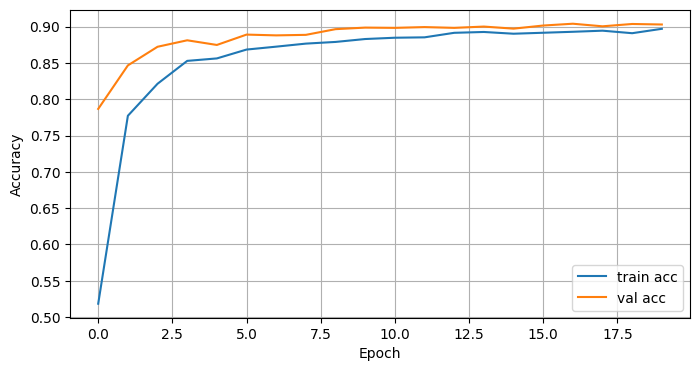

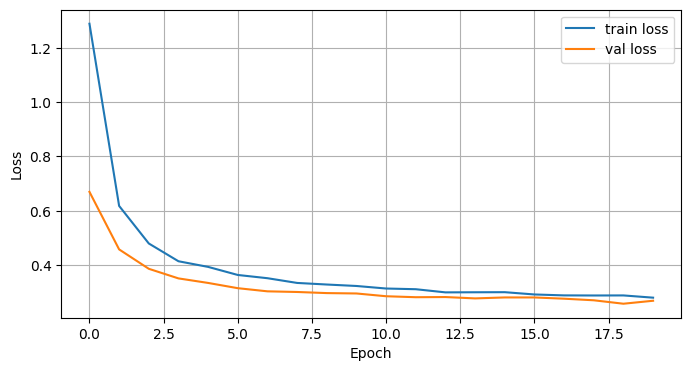

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

hist_df = pd.read_csv("history.csv")

plt.figure(figsize=(8,4))
plt.plot(hist_df["accuracy"], label="train acc")
plt.plot(hist_df["val_accuracy"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(hist_df["loss"], label="train loss")
plt.plot(hist_df["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# Lưu mô hình đã huấn luyện để dùng lại sau này
model.save("scene_mobilenetv2.h5")
print("Saved model to scene_mobilenetv2.h5")

Saved model to scene_mobilenetv2.h5


In [23]:
import os
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# Thư mục chứa ảnh cần phân loại
sample_dir = r"C:\Users\Admin\OneDrive\Documents\File_save_bai_tap_random\Train\sample"

# Load mô hình đã huấn luyện
model = load_model("scene_mobilenetv2.h5")

# Lấy tên các lớp từ train_gen
class_indices = train_gen.class_indices
labels = dict((v, k) for k, v in class_indices.items())

# Lặp qua tất cả ảnh trong thư mục và phân loại
for img_name in os.listdir(sample_dir):
    img_path = os.path.join(sample_dir, img_name)
    if not img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
        continue
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    pred = model.predict(img_array)
    predicted_class = np.argmax(pred, axis=1)[0]
    print(f"{img_name}: {labels[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step
296866297_2929633657.jpg: buildings
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
297024964_2926520320.jpg: buildings
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
298216354_2932688336.jpg: buildings
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
c0c9124a-vinh-ha-long-1.jpg: mountain
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Duong-Pho-1.jpg: street
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
images (1).jpg: mountain
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
images (2).jpg: sea
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
images (3).jpg: sea
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
images (4).jpg: sea
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
images (5).jpg: street
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
images (6).jpg: street
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
images.jpg: mountain
